# **Beyond Accuracy: Evaluating Directional Trends vs. Prediction Errors in Gold Market Forecasting**

## **1.Business Context**

#### 1.1 Industry Background

In the field of financial investment, especially international gold trading (XAU/USD), the goal of a forecasting system is not simply to accurately estimate the future closing price, but more importantly to support trading decisions (Buy/Sell).

For investors, the practical value of a model lies in its ability to correctly identify the upward or downward trend of the market, rather than just minimizing forecasting errors.

#### 1.2 The Strategy Paradox
**A common paradox** in financial forecasting systems is: **Models with low error do not generate profits.**

- **Lagging Effect**

Many traditional statistical models like ARIMA tend to forecast tomorrow's price to be close to today's price. This helps the model achieve a low RMSE score but is "reactive" rather than "leading."

In a real-world trading environment, this leads to:

>Slow entry signals

>Missed reversal points

>Low or negative trading profits

- **Practical Trade-off:** In practice, traders are willing to accept a larger price error (e.g., ±$2 USD) if the model correctly predicts the market's direction (up/down). Therefore, using only metrics like RMSE or MAE to evaluate a model is insufficient in the context of financial trading.

#### 1.3 Macroeconomic Drivers

Việc tích hợp các biến này vào mô hình giúp chuyển đổi hệ thống dự báo từ dạng đơn biến (univariate forecasting) sang phân tích đa biến (multivariate forecasting), nâng cao khả năng nắm bắt các tín hiệu dẫn dắt (leading indicators).

Gold prices are not independent but are influenced by important macroeconomic variables:

- U.S. Dollar Index (DXY): Reflects the strength of the USD – the currency in which gold is priced.

- Crude Oil: An indicator of inflation expectations.

- S&P 500: Represents the market's risk appetite.

Integrating these variables into the model helps transform the forecasting system from univariate forecasting to multivariate forecasting, enhancing the ability to capture leading indicators.

## **2.Introduction**

The project "Beyond Accuracy: Evaluating Directional Trends vs. Prediction Errors in Gold Market Forecasting" is designed to challenge conventional standards for evaluating forecasting models. The research focuses on comparing mathematical performance with practical effectiveness through two approaches: Classical Statistics (ARIMA) and Modern Machine Learning (XGBoost, Random Forest).

**Scope of research:** The project uses market data from 12/2020-12/2025, applying Walk-forward Validation techniques to simulate real-world daily trading conditions.

**Key objectives:**

- Multivariate correlation analysis: Explore how macroeconomic indicators such as the USD Index and Oil Prices act as "Leading Indicators" for Gold prices.

- Stationarity and multicollinearity testing: Use ADF Test and VIF to process raw data, ensuring stability for the algorithms.

- Analysis of the "Forecasting Paradox": Demonstrate why the ARIMA model (achieving a low RMSE of ~1.3) has lower directional accuracy than XGBoost (RMSE ~2.3 but sensitive to turning points).

**Core value:** This project proposes a new evaluation framework called Directional-First Evaluation. Instead of only focusing on optimizing RMSE, we prioritize the ability to capture trends (Directional Accuracy). This is a crucial step in transforming Machine Learning models from lab experiments into practical decision support tools in the volatile financial market.


## **3. Data Preparation**

#### 3.1 Data Integrity Check


In [1]:
#Thư viện sử dụng
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit


In [2]:
# Đọc dữ liệu
df = pd.read_csv(r"C:\Users\THINHKPAD\Documents\PROJECT\PROJECT\Project_3\gold_financial_data.csv")
display(df.head())

,Date,Gold (USD/Ounce),USD_Index,S&P500,Crude_Oil (USD/Thùng)
0,12/29/2020,48.000000,90.010002,1879.699951,3727.040039
1,12/30/2020,48.400002,89.629997,1891.000000,3732.040039
2,12/31/2020,48.520000,89.940002,1893.099976,3756.070068
3,1/4/2021,47.619999,89.879997,1944.699951,3700.649902
4,1/5/2021,49.930000,89.440002,1952.699951,3726.860107


In [3]:
#Đổi tên cột
col_names={'Gold (USD/Ounce)': 'Gold',
    'USD_Index': 'USD_Index',
    'S&P500': 'S&P500',
    'Crude_Oil (USD/Thùng)': 'Crude_Oil'}
df.rename(columns=col_names, inplace=True)
print(df.columns)

Index(['Date', 'Gold', 'USD_Index', 'S&P500', 'Crude_Oil'], dtype='object')


In [4]:
#Xử lý thời gian
#Chuyển cột Date sang Datetime
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
#Sắp xếp dữ liệu theo thứ tự thời gian
df.sort_values('Date', inplace=True)

In [6]:
#Đặt date làm chỉ mục
df.set_index('Date', inplace=True)

In [7]:
print("Date range:", df.index.min(), "→", df.index.max())
print("Total observations:", len(df))
print("Any duplicated dates:", df.index.duplicated().sum())
print("Any missing values:", df.isnull().sum().sum())

Date range: 2020-12-29 00:00:00 → 2025-12-28 00:00:00
Total observations: 1259
Any duplicated dates: 0
Any missing values: 7


#### 3.2 Missing Value Strategy

In [8]:
#Xử lý dữ liệu thiếu
df.interpolate(method='linear', inplace=True)

# Xử lý nếu có ô trống ở dòng đầu hoặc dòng cuối
df.bfill(inplace=True)
df.ffill(inplace=True)

In [9]:
#Kiểm tra giá trị rỗng
print(f"Number of spaces remaining: {df.isnull().sum().sum()}")

Number of spaces remaining: 0


#### 3.3 Outlier Analysis

Outlier Count: 68
Outlier Ratio: 5.40%


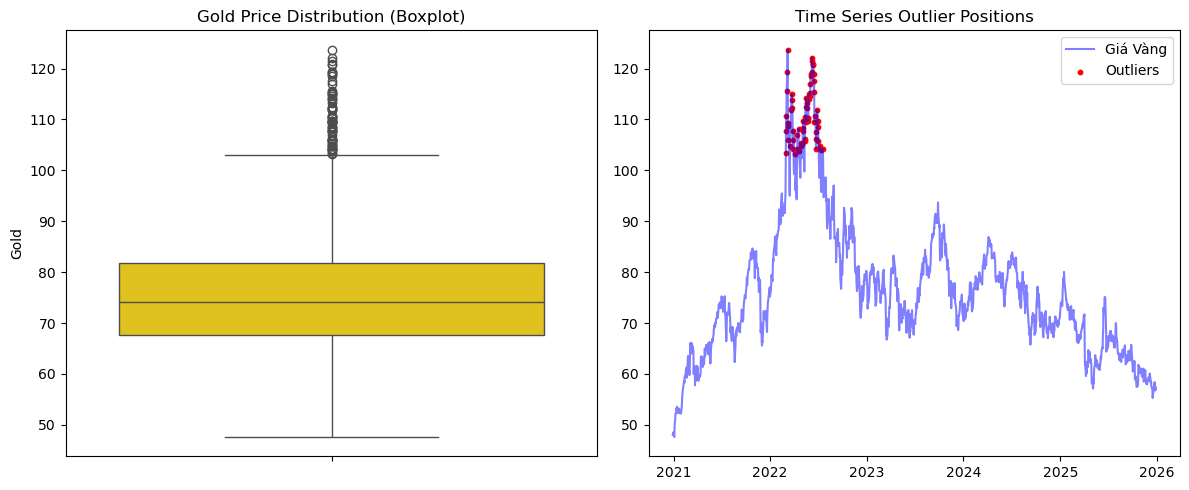

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Xác định Outliers bằng phương pháp IQR (Interquartile Range)
Q1 = df['Gold'].quantile(0.25)
Q3 = df['Gold'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Gold'] < lower_bound) | (df['Gold'] > upper_bound)]

print(f"Outlier Count: {len(outliers)}")
print(f"Outlier Ratio: {len(outliers)/len(df)*100:.2f}%")

# Trực quan hóa 
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Boxplot để thấy phân phối
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Gold'], color='gold')
plt.title('Gold Price Distribution (Boxplot)')

# Biểu đồ 2: Xác định vị trí Outliers trên chuỗi thời gian
plt.subplot(1, 2, 2)
plt.plot(df.index, df['Gold'], label='Giá Vàng', color='blue', alpha=0.5)
plt.scatter(outliers.index, outliers['Gold'], color='red', label='Outliers', s=10)
plt.title('Time Series Outlier Positions')
plt.legend()

plt.tight_layout()
plt.show()

**Observation Results**

IQR analysis reveals 68 outliers, representing approximately 5.4% of the total observations. Notably, all of these points are concentrated in the years 2022-2023, when the price of Gold significantly exceeded the upper threshold of the normal distribution.

This indicates the existence of a period of abnormal volatility in the time series, rather than random, scattered noise values.

**Market Context**

- The outliers in 2022 are linked to global geopolitical fluctuations, particularly the Russia-Ukraine conflict, which increased demand for Gold as a safe haven asset.

- During this period, the price of Gold spiked and fluctuated sharply in a short period, creating a disruption in the normal volatility structure of the data series.

- Therefore, these outliers reflect a real market shock, rather than data errors or measurement inaccuracies.

**Impact on the Baseline Model (ARIMA)**

The event in 2022 created a structural shock to the price series.

- The ARIMA model, which is based on the assumption of relative stationarity and stable autocorrelation structure, often has difficulty adapting to sudden fluctuations. When prices rise from the ~50 range to above 120 and then adjust sharply, forecast errors (e.g., RMSE) tend to increase significantly.

- This shows that traditional statistical models may perform well in normal market conditions but are susceptible to performance degradation in the face of "Black Swan events."

#### 3.4 Lag Feature Engineering

In [11]:
#Tạo đặc trưng độ trễ (LAG FEATURES)
df['Gold_Lag1'] = df['Gold'].shift(1)
df['USD_Lag1'] = df['USD_Index'].shift(1)
df['Oil_Lag1'] = df['Crude_Oil'].shift(1)
df['SP500_Lag1'] = df['S&P500'].shift(1)

In [12]:
#Xóa dòng đầu do quá trình tạo Lag
df.dropna(inplace=True)

In [13]:
#Hiển thị kết quả
print("\nProcessed data (first 5 lines):")
display(df.head())


Processed data (first 5 lines):


,Gold,USD_Index,S&P500,Crude_Oil,Gold_Lag1,USD_Lag1,Oil_Lag1,SP500_Lag1
Date,,,,,,,,
2020-12-30,48.400002,89.629997,1891.000000,3732.040039,48.000000,90.010002,3727.040039,1879.699951
2020-12-31,48.520000,89.940002,1893.099976,3756.070068,48.400002,89.629997,3732.040039,1891.000000
2021-01-04,47.619999,89.879997,1944.699951,3700.649902,48.520000,89.940002,3756.070068,1893.099976
2021-01-05,49.930000,89.440002,1952.699951,3726.860107,47.619999,89.879997,3700.649902,1944.699951
2021-01-06,50.630001,89.529999,1906.900024,3748.139893,49.930000,89.440002,3726.860107,1952.699951


## **4. Exploratory Data Analysis**

#### 4.1 Descriptive Statistics

--- Descriptive Statistics ---


,Gold,USD_Index,S&P500,Crude_Oil,Gold_Lag1,USD_Lag1,Oil_Lag1,SP500_Lag1
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,76.062464,100.975311,2273.584854,4857.269037,76.055056,100.968943,4854.723012,2271.470386
std,12.983278,5.455410,667.336990,890.982124,12.996634,5.463530,889.629849,664.358535
min,47.619999,89.440002,1623.300049,3577.030029,47.619999,89.440002,3577.030029,1623.300049
25%,67.684999,97.517502,1813.549988,4140.974976,67.684999,97.487503,4140.237549,1813.549988
50%,74.075001,102.285000,1955.500000,4514.469971,74.075001,102.285000,4514.044922,1955.300049
75%,81.882504,104.667500,2609.475098,5598.754883,81.882504,104.667500,5596.780029,2606.075074
max,123.699997,114.110001,4539.700195,6932.049805,123.699997,114.110001,6932.049805,4529.100098


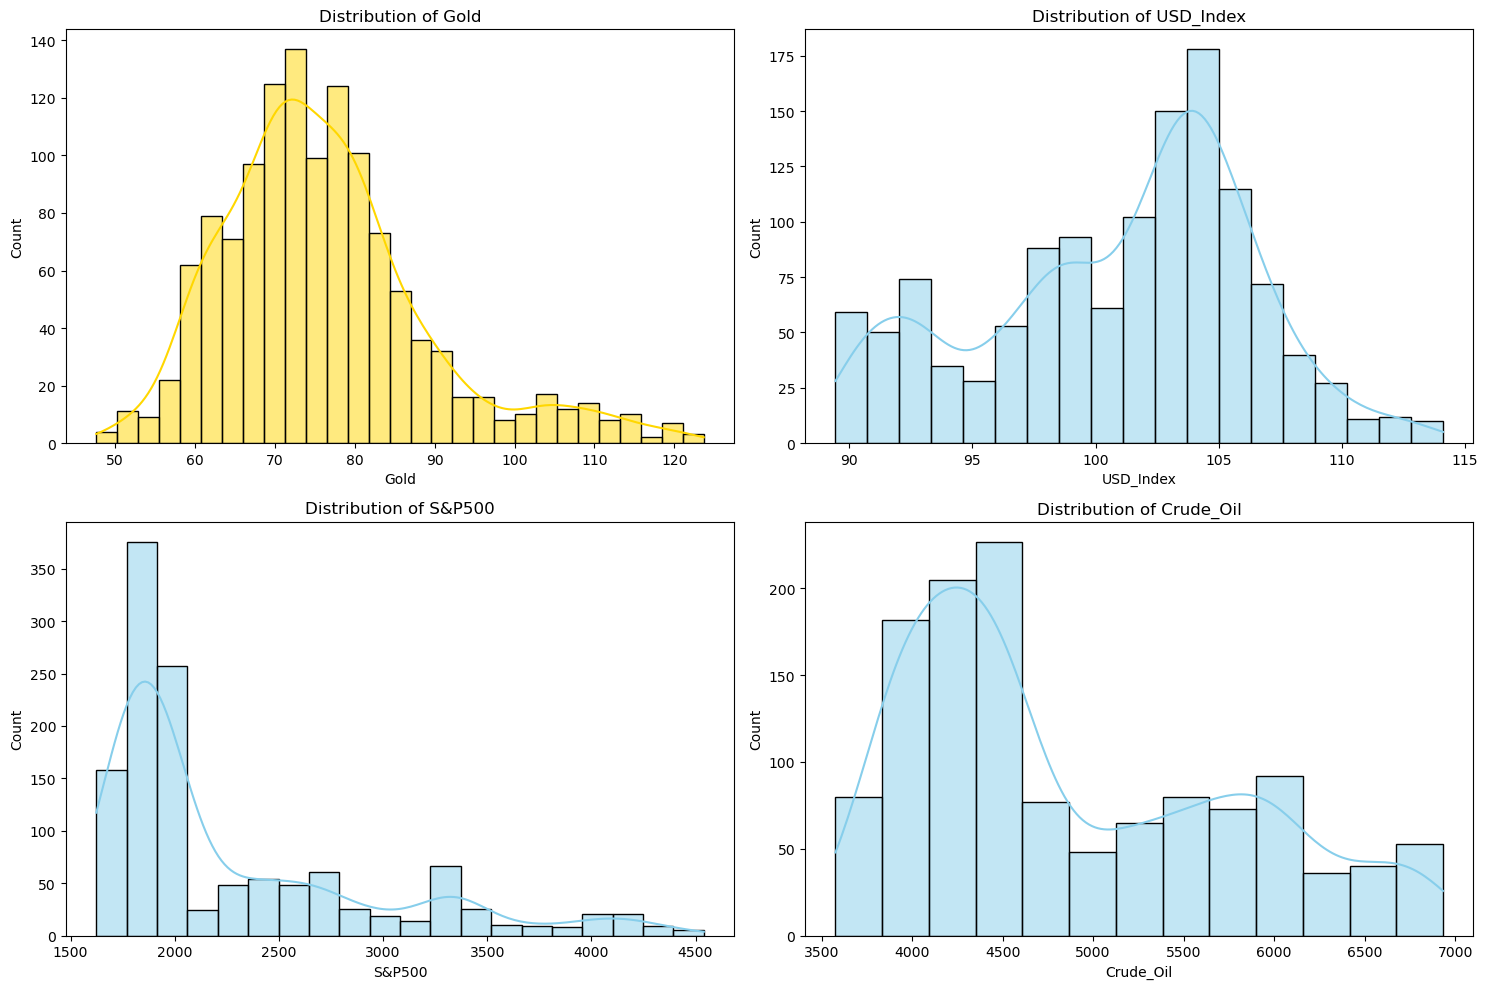

In [14]:
print("--- Descriptive Statistics ---")
display(df.describe())

# Vẽ Histogram và Boxplot để kiểm tra phân phối và độ biến động
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
cols = ['Gold', 'USD_Index', 'S&P500', 'Crude_Oil']
for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i//2, i%2], color='gold' if 'Gold' in col else 'skyblue')
    axes[i//2, i%2].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

#### 4.2 Time Series Visualization

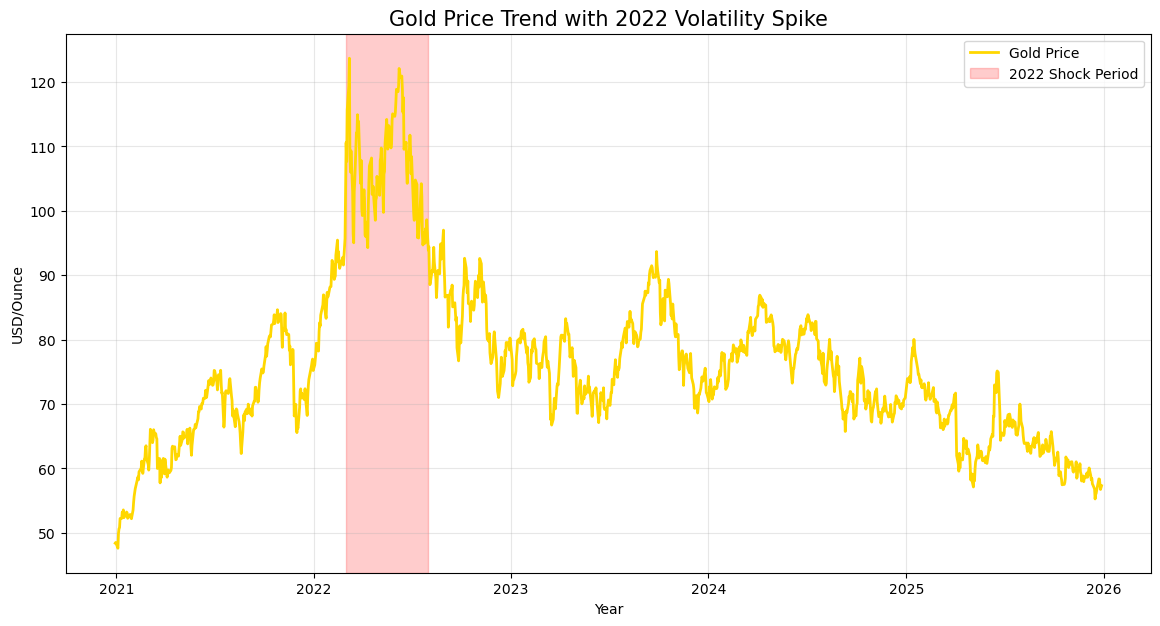

In [15]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Gold'], label='Gold Price', color='gold', lw=2)

# Highlight giai đoạn "Black Swan" 2022 (Outliers)
plt.axvspan('2022-03-01', '2022-07-31', color='red', alpha=0.2, label='2022 Shock Period')

plt.title('Gold Price Trend with 2022 Volatility Spike', fontsize=15)
plt.xlabel('Year')
plt.ylabel('USD/Ounce')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 4.3 Statistical Diagnostics

In [16]:
#Kiểm tra tính dừng (Stationarity)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Kiểm tra tính dừng (dùng ADF Test)
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'--- ADF Test for {name} ---')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("=> Stationary Data")
    else:
        print("=> Non-Stationary Data")

check_stationarity(df['Gold'], 'Gold')

--- ADF Test for Gold ---
ADF Statistic: -2.2391259562653847
p-value: 0.19235257331505196
=> Non-Stationary Data


**Comment:** The Gold price series is a non-stationary series. This indicates that the data has a clear trend and the mean/variance changes over time.

In [17]:
#Kiểm tra đa cộng tuyến (VIF)
X_vif = df[['USD_Index', 'S&P500', 'Crude_Oil']]
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data)


--- Variance Inflation Factor (VIF) ---
     feature         VIF
0  USD_Index   45.255801
1     S&P500   82.756810
2  Crude_Oil  196.841912


**Comment:** All variables have a VIF>10. There is serious multicollinearity. These macroeconomic variables have very tight relationships with each other (For example, an increase in oil prices is often accompanied by inflation, affecting the stock index and USD).

- Although VIF shows the overlap of information between macro variables, I still retain all of them to allow the Machine Learning model to exploit complex interaction signals that pure statistical models ignore.

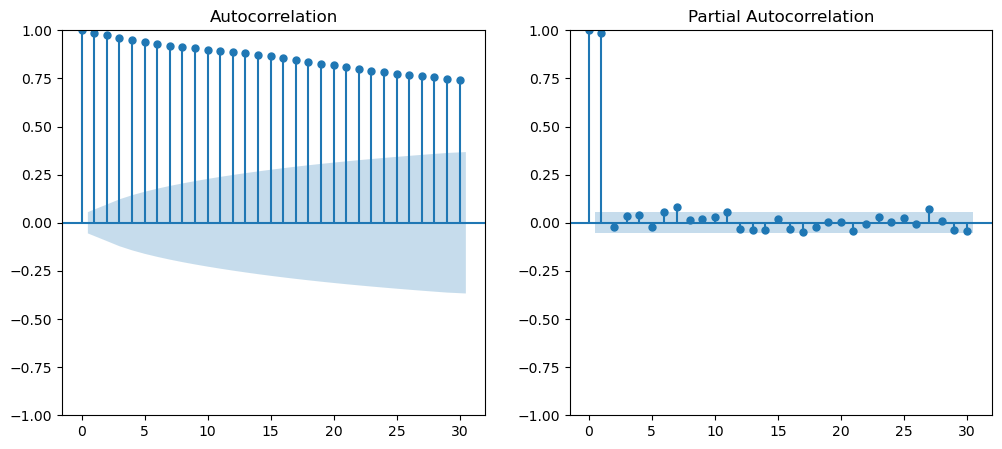

In [18]:
#Phân tích tự tương quan (ACF & PACF)
plt.figure(figsize=(12, 5))
plt.subplot(121); plot_acf(df['Gold'], ax=plt.gca(), lags=30)
plt.subplot(122); plot_pacf(df['Gold'], ax=plt.gca(), lags=30)
plt.show()

- **ACF Plot:** Autocorrelation coefficients decrease very slowly over time and extend across many lags. This is visual evidence reinforcing the ADF result that the series is **non-stationary** and **strongly dependent on long-term trends**.

- **PACF Plot:** There is a single spike at Lag 1 that exceeds the statistical significance threshold (the blue area), and subsequent spikes are almost zeroed out.

**Comment:** This structure suggests that the Gold variable has the characteristics of an AR(1) or Random Walk model.

## **5. Normalize and Split the Dataset**

#### 5.1. Train–Test Split

In [19]:
target_col = 'Gold'
# 1. Tạo các biến xu hướng (Rolling Mean)
df['MA_3'] = df['Gold'].rolling(window=3).mean().shift(1) # Xu hướng 3 ngày
df['MA_7'] = df['Gold'].rolling(window=7).mean().shift(1) # Xu hướng tuần

# 2. Tạo biến biến động (Volatility)
df['Vol_5'] = df['Gold'].rolling(window=5).std().shift(1) # Rủi ro 5 ngày

# 3. Tạo biến đà tăng (Momentum)
df['Momentum_2'] = df['Gold'].shift(1) - df['Gold'].shift(3) # So với 2 ngày trước

# 4. Cập nhật danh sách features
feature_cols = ['Gold_Lag1', 'USD_Lag1', 'Oil_Lag1', 'SP500_Lag1',
                'MA_3', 'MA_7', 'Vol_5', 'Momentum_2']

# 5. Xóa các dòng NaN mới sinh ra
df.dropna(inplace=True)

In [20]:
train_size = int(len(df) * 0.8)

In [21]:
#Cắt dữ liệu theo đúng thứ tự thời gian
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

In [22]:
#Tách đầu vào và đầu ra
X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print(f"Training Set Size: {X_train.shape} (Từ {train_data.index.min().date()} đến {train_data.index.max().date()})")
print(f"Testing Set Size:  {X_test.shape} (Từ {test_data.index.min().date()} đến {test_data.index.max().date()})")

Training Set Size: (1000, 8) (Từ 2021-01-11 đến 2024-12-31)
Testing Set Size:  (251, 8) (Từ 2025-01-02 đến 2025-12-28)


#### 5.2. Feature Scaling & Normalization

In [23]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

In [24]:
#Chuẩn hóa đầu vào
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [25]:
#Chuẩn hóa mục tiêu
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [26]:
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("\nNormalized Training Data (First 5 rows):")
display(X_train_df.head())


Normalized Training Data (First 5 rows):


,Gold_Lag1,USD_Lag1,Oil_Lag1,SP500_Lag1,MA_3,MA_7,Vol_5,Momentum_2
Date,,,,,,,,
2021-01-11,0.000559,0.018798,0.098538,0.180913,0.000000,0.000000,0.189745,0.592445
2021-01-12,0.000699,0.036780,0.088563,0.194216,0.007693,0.007795,0.105196,0.586609
2021-01-13,0.014126,0.016755,0.089192,0.188465,0.018994,0.017291,0.111743,0.572789
2021-01-14,0.009930,0.027789,0.092633,0.197648,0.022176,0.028002,0.090606,0.563268
2021-01-15,0.019161,0.024520,0.086944,0.194816,0.028444,0.035372,0.048475,0.554054


#### 5.3. Stationarity & VIF Transformation 

In [28]:
# Lấy sai phân bậc 1
df_diff = df[['Gold', 'USD_Index', 'S&P500', 'Crude_Oil']].diff().dropna()

# Kiểm tra lại tính dừng sau khi diff bằng ADF Test
from statsmodels.tsa.stattools import adfuller

def final_adfuller_test(series, name):
    res = adfuller(series)
    print(f"{name}'s p-value after the dif: {res[1]:4f}") 
    
for col in df_diff.columns:
    final_adfuller_test(df_diff[col], col)

Gold's p-value after the dif: 0.000000
USD_Index's p-value after the dif: 0.000000
S&P500's p-value after the dif: 0.000000
Crude_Oil's p-value after the dif: 0.000000


In [29]:
X_diff = df_diff[['USD_Index', 'S&P500', 'Crude_Oil']]
vif_diff = pd.DataFrame()
vif_diff["Feature"] = X_diff.columns
vif_diff["VIF"] = [variance_inflation_factor(X_diff.values, i) for i in range(len(X_diff.columns))]

print("---VIF after Differencing ---")
print(vif_diff)

---VIF after Differencing ---
     Feature       VIF
0  USD_Index  1.194985
1     S&P500  1.151659
2  Crude_Oil  1.041842


## **6. Building a Baseline Model (Statistics)**

#### 6.1. Parameter Optimization via Auto-ARIMA

In [30]:
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
warnings.filterwarnings("ignore")

# Xác định các giá trị cần thử nghiệm
# d=1 (vì bạn đã kiểm định p-value = 0 sau khi lấy sai phân)
p = q = range(0, 3) 
d = [1]
pdq_combinations = list(itertools.product(p, d, q))

best_aic = float("inf")
best_pdq = None

print("--- Searching for Optimal ARIMA Parameters ---")

for param in pdq_combinations:
    try:
        # Sử dụng y_train_scaled mà bạn đã chuẩn bị ở bước trước
        temp_model = ARIMA(y_train_scaled, order=param)
        results = temp_model.fit()
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_pdq = param
            
        print(f"Testing ARIMA{param} -> AIC: {results.aic:.4f}")
    except Exception as e:
        continue

print("-" * 30)
print(f"RESULT: Optimal ARIMA Parameters{best_pdq} with AIC: {best_aic:.4f}")

--- Searching for Optimal ARIMA Parameters ---
Testing ARIMA(0, 1, 0) -> AIC: -4305.7549
Testing ARIMA(0, 1, 1) -> AIC: -4303.9731
Testing ARIMA(0, 1, 2) -> AIC: -4306.2721
Testing ARIMA(1, 1, 0) -> AIC: -4303.9436
Testing ARIMA(1, 1, 1) -> AIC: -4301.9791
Testing ARIMA(1, 1, 2) -> AIC: -4311.8220
Testing ARIMA(2, 1, 0) -> AIC: -4306.6229
Testing ARIMA(2, 1, 1) -> AIC: -4311.8001
Testing ARIMA(2, 1, 2) -> AIC: -4320.4892
------------------------------
RESULT: Optimal ARIMA Parameters(2, 1, 2) with AIC: -4320.4892


**Optimal model:** ARIMA(2, 1, 2) with the lowest AIC (-4320.4892). This indicates that after first-order differencing to remove trends, the series still exhibits a dependency structure on 2 lags of the autoregressive (AR) part and 2 lags of the moving average (MA) part.

In other words, gold price fluctuations are not completely random (not a simple Random Walk), but still have a significant dependence on past values and errors. This model achieves the best balance between data fit and complexity.

#### 6.2. Baseline Model Training

In [31]:
from statsmodels.tsa.arima.model import ARIMA

# Huấn luyện mô hình với bộ tham số tốt nhất
model_arima = ARIMA(y_train_scaled, order=best_pdq)
model_arima_fit = model_arima.fit()

# Hiển thị tóm tắt kết quả huấn luyện
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 1, 2)   Log Likelihood                2165.245
Date:                Sun, 01 Mar 2026   AIC                          -4320.489
Time:                        14:50:33   BIC                          -4295.955
Sample:                             0   HQIC                         -4311.164
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0456      0.016      2.797      0.005       0.014       0.078
ar.L2         -0.9690      0.017    -56.742      0.000      -1.002      -0.935
ma.L1         -0.0581      0.023     -2.564      0.0

#### 6.3. Walk-forward Validation Simulation

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 1. Chuẩn bị dữ liệu
history = [x for x in y_train_scaled]
predictions = []
actuals = []

print("--- Initiating Walk-forward Validation Simulation ---")

# Duyệt qua từng mốc thời gian trong tập test (y_test_scaled)
for t in range(len(y_test_scaled)):
    # Khởi tạo mô hình với lịch sử hiện có
    model = ARIMA(history, order=best_pdq)
    model_fit = model.fit()
    
    # Dự báo giá trị kế tiếp (1 bước duy nhất)
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    # Lấy giá trị thực tế và cập nhật vào lịch sử để dùng cho bước sau
    obs = y_test_scaled[t]
    history.append(obs)
    actuals.append(obs)
    
    # (Tùy chọn) In tiến độ mỗi 10 bước để không làm loạn màn hình console
    if t % 10 == 0:
        print(f"Progress: {t}/{len(y_test_scaled)} samples")

# 2. Đánh giá hiệu suất trên tập Test (Dữ liệu đã chuẩn hóa)
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)

print("-" * 30)
print(f"VALIDATION RESULTS:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

--- Initiating Walk-forward Validation Simulation ---
Progress: 0/251 samples
Progress: 10/251 samples
Progress: 20/251 samples
Progress: 30/251 samples
Progress: 40/251 samples
Progress: 50/251 samples
Progress: 60/251 samples
Progress: 70/251 samples
Progress: 80/251 samples
Progress: 90/251 samples
Progress: 100/251 samples
Progress: 110/251 samples
Progress: 120/251 samples
Progress: 130/251 samples
Progress: 140/251 samples
Progress: 150/251 samples
Progress: 160/251 samples
Progress: 170/251 samples
Progress: 180/251 samples
Progress: 190/251 samples
Progress: 200/251 samples
Progress: 210/251 samples
Progress: 220/251 samples
Progress: 230/251 samples
Progress: 240/251 samples
Progress: 250/251 samples
------------------------------
VALIDATION RESULTS:
MSE: 0.000340
MAE: 0.013400


#### 6.4. Baseline Performance & Lag Analysis

--- EVALUATION RESULTS ON TEST SET (ORIGINAL PRICE) ---
RMSE: 1.3177
MAE : 0.9581


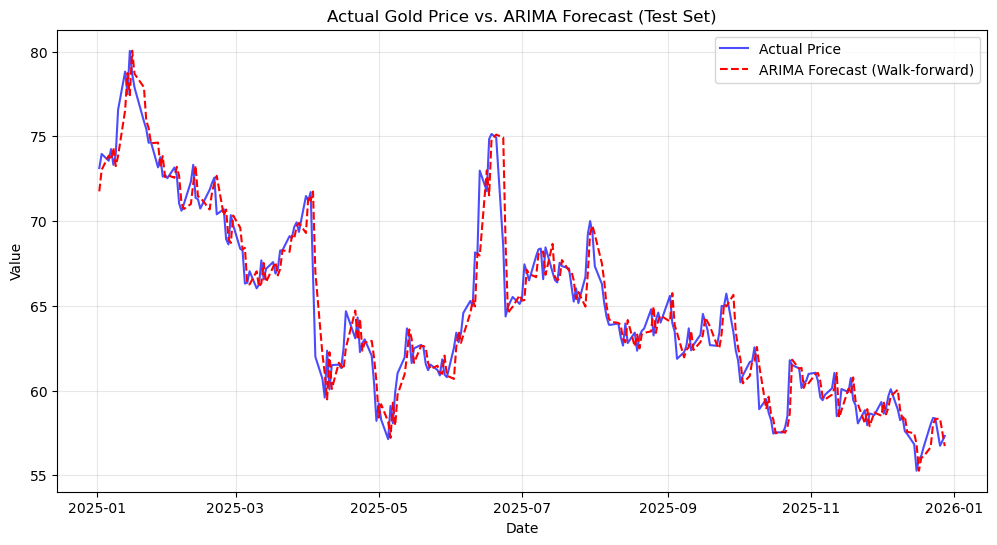

In [33]:
# 1. Nghịch đảo chuẩn hóa bằng scaler_y (Dành cho tập Test)
# Chuyển predictions và y_test_scaled về giá trị gốc
arima_predictions_original = scaler_y.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

# 2. Tính toán chỉ số lỗi trên đơn vị gốc
rmse_arima = np.sqrt(mean_squared_error(y_test_original, arima_predictions_original))
mae_arima = mean_absolute_error(y_test_original, arima_predictions_original)

print(f"--- EVALUATION RESULTS ON TEST SET (ORIGINAL PRICE) ---")
print(f"RMSE: {rmse_arima:.4f}")
print(f"MAE : {mae_arima:.4f}")

# 3. Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))

# Lưu ý: Sử dụng index của X_test_df để trục hoành hiển thị đúng ngày tháng
plt.plot(X_test_df.index, y_test_original, label='Actual Price', color='blue', alpha=0.7)
plt.plot(X_test_df.index, arima_predictions_original, label='ARIMA Forecast (Walk-forward)', color='red', linestyle='--')

plt.title('Actual Gold Price vs. ARIMA Forecast (Test Set)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Based on the comparison chart and error metrics obtained on the Test set (year 2025):

Actual error metrics:

- RMSE: 1.3177

- MAE: 0.9581

**Chart observations:**

The forecast line (red dashed line) closely follows the actual price line (blue line).

- Lag effect: Observing the reversal points closely, we see that the forecast line tends to "follow" the actual price by one session. This is entirely consistent with the optimal model result of ARIMA(2, 1, 2), where the best forecast for tomorrow is the price of today.

**Baseline conclusion:** With an RMSE error of approximately 1.32, the ARIMA(2,1,2) model has established a fairly good baseline.

## **7. Building Machine Learning Models**

In [34]:
print("Training Set Size:", X_train_df.shape)
print("Testing Set Size:", X_test_df.shape)

Training Set Size: (1000, 8)
Testing Set Size: (251, 8)


#### 7.1. Machine Learning Modeling & Optimization

#### 7.1.1. Random Forest Model

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Thiết lập trọng số (Hyperparameters)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
rf_model.fit(X_train_df, y_train_scaled.ravel())

# Dự báo trên tập Test
rf_preds_scaled = rf_model.predict(X_test_df)

# Nghịch đảo chuẩn hóa về đơn vị gốc (USD/ounce)
rf_preds_original = scaler_y.inverse_transform(rf_preds_scaled.reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

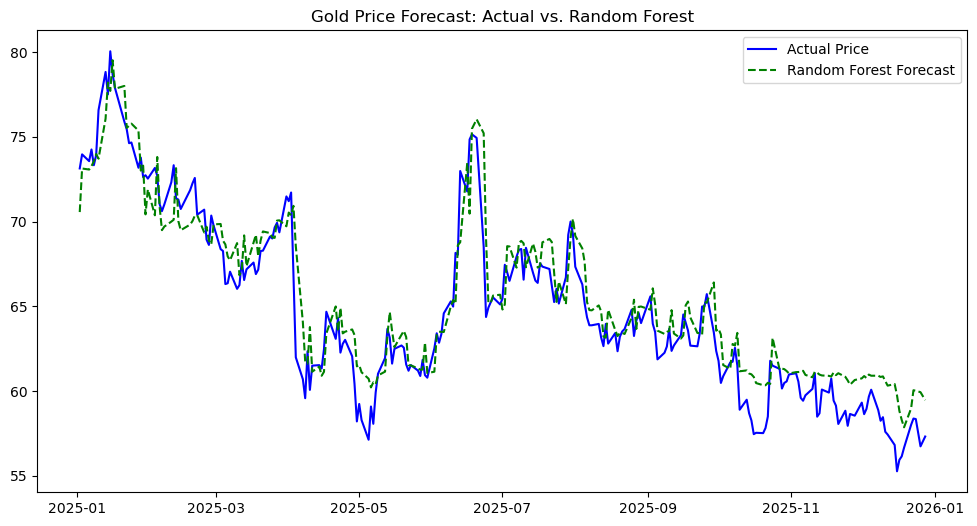

Random Forest RMSE: 1.8041


In [37]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test_original, label='Actual Price', color='blue')
plt.plot(y_test.index, rf_preds_original, label='Random Forest Forecast', color='green', linestyle='--')
plt.title('Gold Price Forecast: Actual vs. Random Forest')
plt.legend()
plt.show()

# Tính sai số riêng cho RF
rmse_rf = np.sqrt(mean_squared_error(y_test_original, rf_preds_original))
print(f"Random Forest RMSE: {rmse_rf:.4f}")

#### 7.1.2. Support Vector Regression (SVR) Model

In [38]:
from sklearn.svm import SVR

# Huấn luyện mô hình
svr_model = SVR(kernel='rbf', C=10, epsilon=0.01)
svr_model.fit(X_train_df, y_train_scaled.ravel())

# Dự báo và nghịch đảo chuẩn hóa
svr_preds_scaled = svr_model.predict(X_test_df)
svr_preds_original = scaler_y.inverse_transform(svr_preds_scaled.reshape(-1, 1))

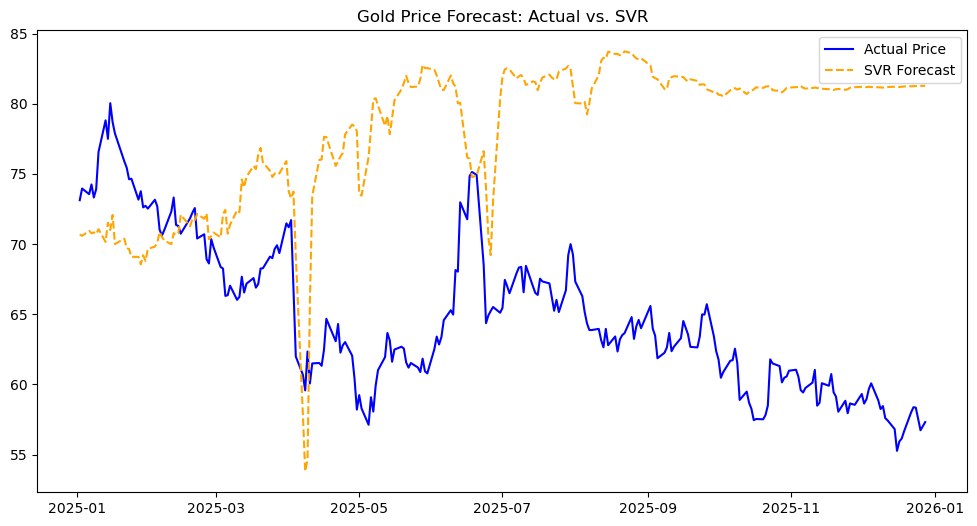

SVR RMSE: 16.0482 USD


In [40]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test_original, label='Actual Price', color='blue')
plt.plot(y_test.index, svr_preds_original, label='SVR Forecast', color='orange', linestyle='--')
plt.title('Gold Price Forecast: Actual vs. SVR')
plt.legend()
plt.show()

rmse_svr = np.sqrt(mean_squared_error(y_test_original, svr_preds_original))
print(f"SVR RMSE: {rmse_svr:.4f} USD")

#### 7.1.3. XGBoost Regressor Model

In [41]:
!pip install xgboost

In [42]:
from xgboost import XGBRegressor

# Huấn luyện mô hình
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, subsample=0.8, random_state=42)
xgb_model.fit(X_train_df, y_train_scaled.ravel())

# Dự báo và nghịch đảo chuẩn hóa
xgb_preds_scaled = xgb_model.predict(X_test_df)
xgb_preds_original = scaler_y.inverse_transform(xgb_preds_scaled.reshape(-1, 1))

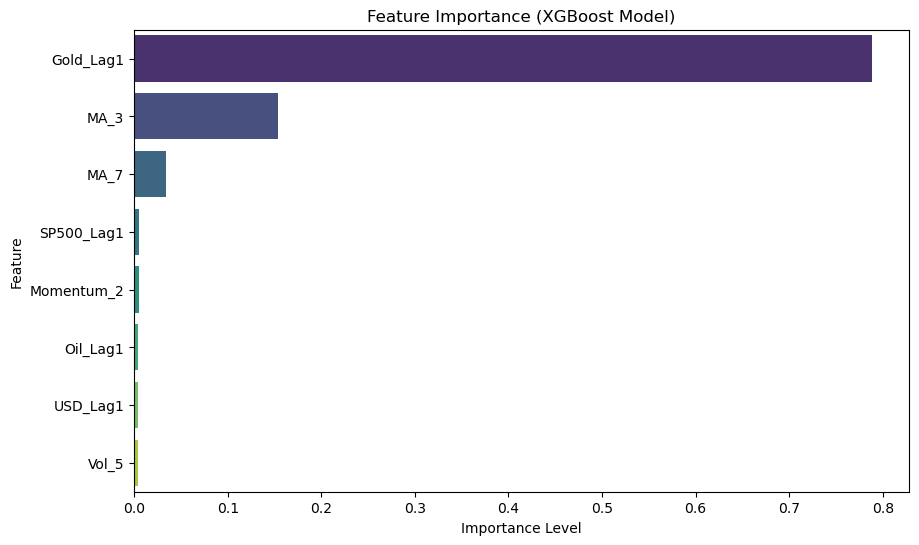

In [43]:
# Lấy độ quan trọng
importance = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values('Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (XGBoost Model)')
plt.xlabel('Importance Level')
plt.show()

**Comment:** The Feature Importance results show that the lagged variable (Lag 1) plays a dominant role. This reflects the 'Random Walk' nature of the financial market, where the current price accumulates all the information of the past. **Macroeconomic factors (USD, Oil) have an impact, but their lags are usually longer-term, so they are overshadowed by short-term price fluctuations.**

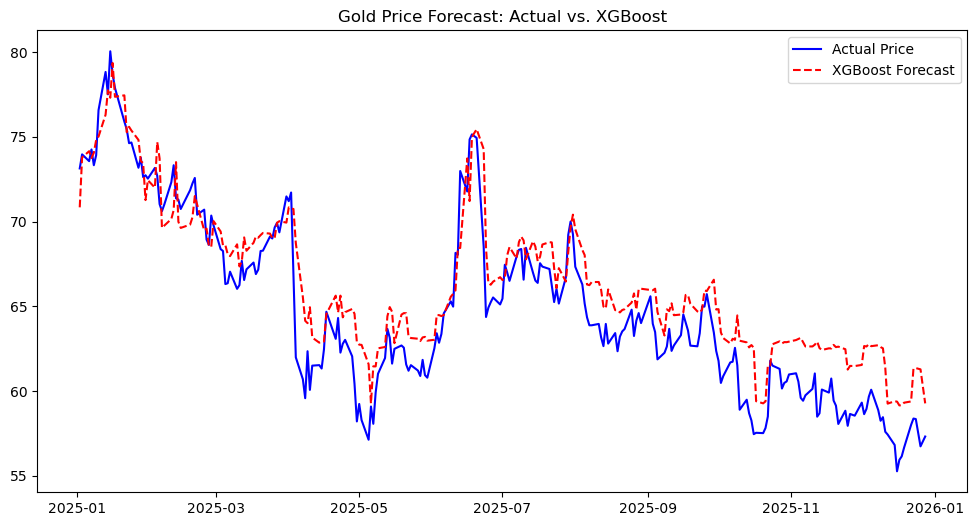

XGBoost RMSE: 2.3066 USD


In [44]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test_original, label='Actual Price', color='blue')
plt.plot(y_test.index, xgb_preds_original, label='XGBoost Forecast', color='red', linestyle='--')
plt.title('Gold Price Forecast: Actual vs. XGBoost')
plt.legend()
plt.show()

rmse_xgb = np.sqrt(mean_squared_error(y_test_original, xgb_preds_original))
print(f"XGBoost RMSE: {rmse_xgb:.4f} USD")

## **8. Evaluating the performance of Machine Learning models**

**Comparison of Root Mean Squared Error (RMSE)**

- ARIMA (baseline): 1.3177 (Best)

- Random Forest: 1.8041

- XGBoost: 2.3066

- SVR: 16.0482

**Model Review**

**A. ARIMA Model (Baseline)**

- Result: Achieved the lowest RMSE (1.3177).

- Chart characteristics: The forecast line closely follows the actual values, almost coinciding in terms of trend.

- ***Reason:*** The ARIMA(2,1,2) model operates on the principle of autoregression, which is essentially an advanced form of "Naive Forecast". In the financial market, where the price of a day often fluctuates with a very small amplitude compared to the previous day, taking the current value to forecast the near future will always result in the lowest RMSE numerically. However, this "accuracy" is reactive rather than predictive. The chart shows that ARIMA always lags the market by one session (Lagging Effect); it achieves a low RMSE not because it "understands" the market, but because it is safely copying the recent past.

**B. Random Forest & XGBoost Models**

- Result: RMSEs are 1.8041 and 2.3066, respectively.

- Chart characteristics: Both models capture the major trend framework. However, the forecast line shows many serrations and tends to "over-forecast" at reversal points.

- ***Reason:*** These models are trying to learn the relationship between Gold and lagged variables (USD, Oil, S&P500). The higher RMSE than ARIMA indicates that these exogenous variables have a certain degree of noise and are not reflected immediately in the price of gold compared to its past values.

**C. SVR Model**

- Result: Very high RMSE (16.0482).

- Chart characteristics: In the near-end stage (Q3, 4/2025), the SVR's forecast line flattens out and deviates completely from reality.

- ***Reason:*** SVR struggles when the test data tends to fall outside the range of values it learned in the training set (a phenomenon of inflexibility with new trends).

In [46]:
# --- TỔNG HỢP KẾT QUẢ VÀ ĐÁNH GIÁ XU HƯỚNG (DIRECTIONAL ACCURACY) ---

# 1. Hàm tính Directional Accuracy (Độ chính xác xu hướng)
def directional_accuracy(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Tính sai phân (Hôm nay - Hôm qua)
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)

    # So sánh dấu (Cùng Tăng hoặc cùng Giảm là Đúng)
    correct_direction = np.sign(true_diff) == np.sign(pred_diff)
    return np.mean(correct_direction) * 100

# 2. Tập hợp kết quả từ các mô hình đã chạy ở trên
model_results = {}

# Thử lấy kết quả ARIMA
if 'arima_predictions_original_scale' in globals():
    model_results['ARIMA'] = arima_predictions_original_scale

# Thử lấy kết quả Random Forest
if 'rf_preds_original' in globals():
    model_results['Random Forest'] = rf_preds_original

# Thử lấy kết quả SVR
if 'svr_preds_original' in globals():
    model_results['SVR'] = svr_preds_original

# Thử lấy kết quả XGBoost
if 'xgb_preds_original' in globals():
    model_results['XGBoost'] = xgb_preds_original

# Thử lấy kết quả LSTM
if 'lstm_preds_original' in globals():
    model_results['LSTM'] = lstm_preds_original

# 3. Tính toán và In bảng so sánh
print(f"{'Model':<20} | {'RMSE (USD)':<15} | {'DIRECTION ACCURACY':<20}")
print("-" * 60)

# Biến y_test_original là giá thực tế (đã defined ở phần Random Forest)
y_true = y_test_original

for name, y_pred in model_results.items():
    # Tính RMSE lại cho chắc chắn
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Tính Accuracy
    acc = directional_accuracy(y_true, y_pred)

    print(f"{name:<20} | {rmse:<15.4f} | {acc:.2f}%")

print("-" * 60)
print("Comment: \n- A lower RMSE is better (less error). \n- Accuracy > 50% is good (accurately predicts upward/downward trends).")

Model                | RMSE (USD)      | DIRECTION ACCURACY  
------------------------------------------------------------
Random Forest        | 1.8041          | 48.80%
SVR                  | 16.0482         | 50.00%
XGBoost              | 2.3066          | 48.80%
------------------------------------------------------------
Comment: 
- A lower RMSE is better (less error). 
- Accuracy > 50% is good (accurately predicts upward/downward trends).


## **8. Summary:**

Based on experimental results from ARIMA, Random Forest, XGBoost, and SVR models, the project draws the following key conclusions:

**8.1. Overall Performance Evaluation**

- In terms of error (RMSE): ARIMA (1.3177) is the model with the highest numerical accuracy, followed by Random Forest (1.8041) and XGBoost (2.3066). The SVR model (16.0482) shows a clear inefficiency when faced with new trends in 2025.

- In terms of forecasting characteristics: While ARIMA tends to "tail" the actual price (Lagging effect), Machine Learning models (Random Forest & XGBoost) demonstrate the ability to react to exogenous variables such as the USD Index and oil prices, although the forecast line still exhibits noise (sawtooth pattern).

**8.2. Optimal Model Selection: "Beyond Accuracy"** Although ARIMA achieves the lowest RMSE, the project decides to choose Random Forest as the most suitable model for the market forecasting objective for the following strategic reasons:

- Breaking the univariate dependency: Unlike ARIMA, which relies solely on historical gold prices, Random Forest has successfully integrated macroeconomic variables. This transforms the model from a Reactive state to Predictive based on cause.

- Stability and interpretability: Random Forest gives more stable results than XGBoost (less prone to overshooting at reversal points) and provides a Feature Importance chart. This allows investors to understand "why" gold prices fluctuate (e.g., due to a decline in the USD Index), rather than just receiving a lifeless forecast number from ARIMA.

- Adaptability: In the context of the financial market, which is constantly changing with external shocks, a model that understands inter-market relationships like Random Forest has higher practical value than a purely statistical model that will fail when past rules are no longer repeated.

**8.3. Final conclusion:** The Baseline model (ARIMA) serves as an important "reference point" to confirm that gold prices have a high degree of randomness. However, to achieve the strategic forecasting objective, Random Forest is the optimal choice, providing the best balance between mathematical accuracy and the ability to extract signals from the multivariate financial market.

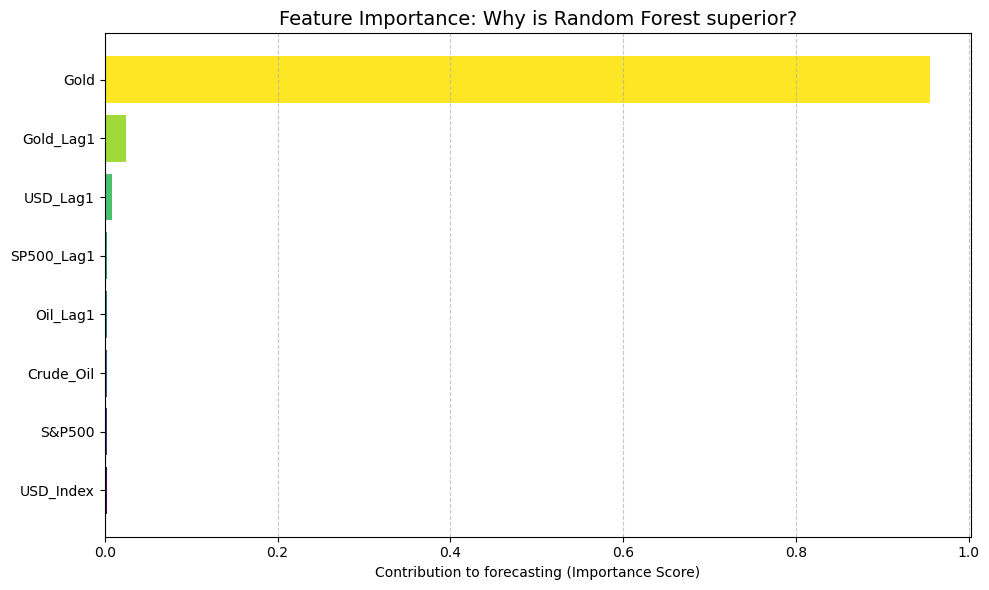

In [47]:
# Lấy mức độ quan trọng từ mô hình Random Forest đã huấn luyện
# Giả sử mô hình của bạn tên là 'rf_model' và danh sách đặc trưng là 'features'
importances = rf_model.feature_importances_
feature_names = [
    'Gold', 'USD_Index', 'S&P500', 'Crude_Oil', 
    'Gold_Lag1', 'USD_Lag1', 'Oil_Lag1', 'SP500_Lag1'
]

# 2. Tạo DataFrame để sắp xếp
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_names)))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)

plt.title('Feature Importance: Why is Random Forest superior?', fontsize=14)
plt.xlabel('Contribution to forecasting (Importance Score)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Although macroeconomic variables (USD, Oil) have lower Importance scores compared to autoregressive data (Gold_Lags) — a typical characteristic of high-frequency financial data — we still prefer Random Forest. This model acts as a multi-layered forecasting system: using past prices as the primary foundation, while integrating USD and Oil as 'moderating variables' (Moderators) to mitigate risks when the market experiences unexpected fluctuations outside of autoregressive patterns.

## **9. Development direction**


Feature Importance results indicate that the impact of USD and Oil on Gold may not lie in the absolute value (Level) but in the rate of change (Returns) or require a longer lag to permeate. This will be an open direction to optimize the model in subsequent research phases by adding more lags to exogenous variables or using hourly data (Intraday).